# Imports

In [1]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import cv2
from scipy.stats import ks_2samp

# Methods

In [4]:
def apply_fourier_transform(image):
    """Aplica a Transformada de Fourier a uma imagem e retorna a magnitude e a transformada."""
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.log(np.abs(f_shift) + 1)
    return magnitude, f_shift

In [5]:
def filtro_passa_baixa(img, sigma):
    """Aplica um filtro passa-baixa na imagem usando a transformada de Fourier"""
    # Aplicar a Transformada de Fourier
    dft = np.fft.fft2(img)

    # Calculando valores para aplicar no filtro passa baixa
    nx = dft.shape[1]
    ny = dft.shape[0]

    cxrange = np.concatenate(
        (
            np.arange(0, nx // 2 + 1),
            np.arange(-nx // 2 + 1, 0)
        )
    )
    cyrange = np.concatenate(
        (
            np.arange(0, ny // 2 + 1),
            np.arange(-ny // 2 + 1, 0)
        )
    )
    cx, cy = np.meshgrid(cxrange, cyrange)

    fxrange = cxrange * 2 * (np.pi / nx)
    fyrange = cyrange * 2 * (np.pi / ny)

    fx, fy = np.meshgrid(fxrange, fyrange)
    return np.exp(-(fx**2 + fy**2) / (2 * (sigma**2)))

# Parameters

In [6]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / 'atv03_lista-final'

# Questão 01

In [ ]:
def read_img(file_path: str):
    """Lendo imagem em escala de cinza"""
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    return img

def apply_fourier_transform(image):
    """Aplica a transformada de Fourier e retorna a magnitude e a transformada deslocada"""
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.log(np.abs(f_shift) + 1)
    return magnitude, f_shift

In [ ]:
imgs = {
    "Pattern1": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1.png'),
        "img_fft": None
    },
    "Pattern1_blur": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1_blur.png'),
        "img_fft": None
    },
    "Pattern1_blur2": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1_blur2.png'),
        "img_fft": None
    },
    "Pattern2": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern2.png'),
        "img_fft": None
    },
}
for key, value in imgs.items():
    imgs[key]["img_fft"] = apply_fourier_transform(value["img"])[0]

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
for i, (key, img) in enumerate(imgs.items()):
    ax[i // 2, i % 2].imshow(img["img"], cmap='gray')
    ax[i // 2, i % 2].set_title(key)
    ax[i // 2, i % 2].axis('off')


## A)

In [ ]:
lista_imgs = [
    "Pattern1",
    "Pattern2",
]

fig = plt.figure(figsize=(16, 18))
axes = []
for i in range(2):
    axes.append(fig.add_subplot(3, 2, i + 1))
    axes.append(fig.add_subplot(3, 2, i + 3))
    axes.append(fig.add_subplot(3, 2, i + 5, projection='3d'))

for i, key in enumerate(lista_imgs):
    # Imagem original
    axes[i * 3].imshow(imgs[key]["img"], cmap='gray')
    axes[i * 3].set_title(key)
    axes[i * 3].axis('off')

    # FFT 2D
    axes[i * 3 + 1].imshow(imgs[key]["img_fft"], cmap='gray')
    axes[i * 3 + 1].set_title(key + " - FFT")
    axes[i * 3 + 1].axis('off')

    # FFT 3D
    fft_magnitude = imgs[key]["img_fft"]
    x = np.arange(fft_magnitude.shape[1])
    y = np.arange(fft_magnitude.shape[0])
    X, Y = np.meshgrid(x, y)
    axes[i * 3 + 2].plot_surface(X, Y, fft_magnitude, cmap='jet')
    axes[i * 3 + 2].set_title(key + " - FFT 3D")

fig.tight_layout()
fig.savefig(path_assets / "atv03_q01-01.png", dpi=400)

## B)

In [ ]:
lista_imgs = [
    "Pattern1",
    "Pattern1_blur",
    "Pattern1_blur2",
]

fig = plt.figure(figsize=(16, 18))
axes = []

# Criando eixos para imagens 2D e FFT
for i in range(3):  # 3 colunas
    axes.append(fig.add_subplot(3, 3, i + 1))  # Linha 1: Imagens originais
    axes.append(fig.add_subplot(3, 3, i + 4))  # Linha 2: FFT 2D
    axes.append(fig.add_subplot(3, 3, i + 7, projection='3d'))  # Linha 3: FFT 3D

for i, key in enumerate(lista_imgs):
    # Imagem original
    axes[i * 3].imshow(imgs[key]["img"], cmap='gray')
    axes[i * 3].set_title(key)
    axes[i * 3].axis('off')

    # FFT 2D
    axes[i * 3 + 1].imshow(imgs[key]["img_fft"], cmap='gray')
    axes[i * 3 + 1].set_title(key + " - FFT")
    axes[i * 3 + 1].axis('off')

    # FFT 3D
    fft_magnitude = imgs[key]["img_fft"]
    x = np.arange(fft_magnitude.shape[1])
    y = np.arange(fft_magnitude.shape[0])
    X, Y = np.meshgrid(x, y)
    axes[i * 3 + 2].plot_surface(X, Y, fft_magnitude, cmap='jet')
    axes[i * 3 + 2].set_title(key + " - FFT 3D")

fig.tight_layout()
fig.savefig(path_assets / "atv03_q01-02.png", dpi=400)
plt.show()

# Questão 02

In [45]:
img = cv2.imread(path_imgs_atv / "Q2" / "XRay.png", cv2.IMREAD_GRAYSCALE)
img = img[:, 2:]

In [101]:
img[190:200, 100:200].max()

np.uint8(242)

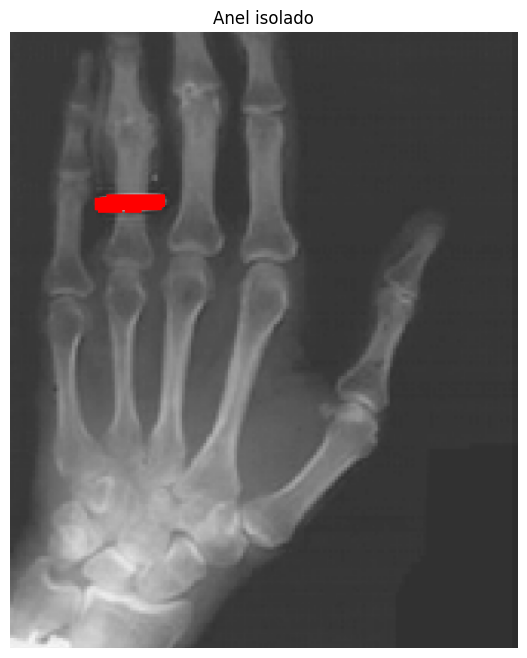

In [108]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Copia da imagem original
img_cut = img.copy()

# Separar em 2 quadrantes a imagem
img_cut_cima = img_cut[:(img_cut.shape[0] // 2), :].copy()
img_cut_baixo = img_cut[(img_cut.shape[0] // 2):, :].copy()

# Zerando parte de baixo
img_cut_baixo[:] = 0

# Aplicar threshold
_, mascara = cv2.threshold(img_cut_cima, 242, 255, cv2.THRESH_BINARY)

# Mascara inferior de zeros
mascara_inferior = np.zeros_like(img_cut_baixo)

# Junta as matrizes
mascara = np.concatenate((mascara, mascara_inferior), axis=0)

# Opcional: realizar operações morfológicas para remover pequenos ruídos
kernel = np.ones((5, 5), np.uint8)
mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=1)
mascara = cv2.dilate(mascara, np.ones((7, 7), np.uint8), iterations=2)

# Mantendo em tons de cinza, mas com 3 canais
img_rec = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# Colocar anel na imagem
img_rec[mascara > 0] = [255, 0, 0]  # Vermelho

# Mostrar resultado
plt.figure(figsize=(8, 8))
plt.imshow(img_rec)
plt.axis('off')
plt.title('Anel isolado')
plt.show()


In [ ]:
# Mão
img_test = img.copy()
k_bins = 4
quantils = np.arange(0, 1, 1 / k_bins)
img_quantiles = np.quantile(img_test, quantils)
values = ((img_quantiles[1:] + img_quantiles[:-1]) / 2).astype(int)
for pixel in range(img_test.shape[0]):
    for j in range(img_test.shape[1]):
        idx = np.digitize(img_test[pixel, j], img_quantiles) - 1
        idx = np.clip(idx, 0, len(values) - 1)
        img_test[pixel, j] = values[idx]

img_bin = cv2.threshold(img_test, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
img_close = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernel, iterations=1)
img_gaussian = cv2.GaussianBlur(img_close, (3, 3), 1)

(np.float64(-0.5), np.float64(605.5), np.float64(735.5), np.float64(-0.5))

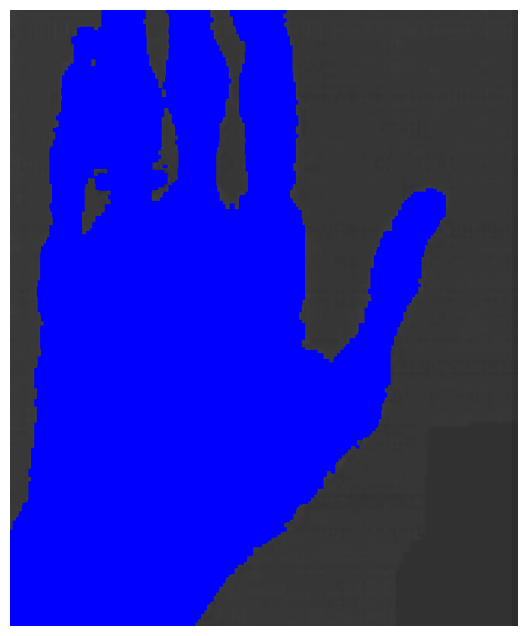

In [171]:
img_rec = img.copy()
img_rec = cv2.cvtColor(img_rec, cv2.COLOR_GRAY2RGB)
img_rec[img_gaussian > 0] = [0, 0, 255]  # Vermelho


plt.figure(figsize=(8, 8))
plt.imshow(img_rec, cmap='gray')
plt.axis('off')
#plt.imshow(img_test, cmap='gray')

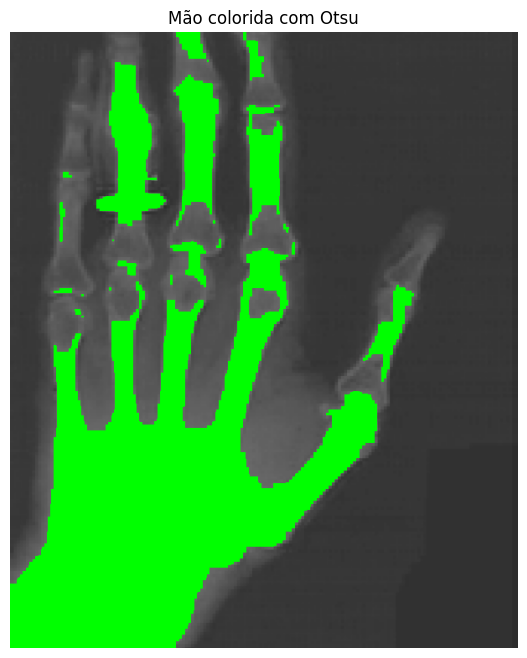

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar a imagem original
# img = cv2.imread('XRay.png', cv2.IMREAD_GRAYSCALE)

# Limiar baixo para segmentar a mão inteira
_, mascara_mao = cv2.threshold(img, 60, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

# Opcional: operações morfológicas para suavizar a segmentação
kernel = np.ones((5, 5), np.uint8)
mascara_mao = cv2.morphologyEx(mascara_mao, cv2.MORPH_CLOSE, kernel, iterations=5)

mascara_mao = cv2.dilate(mascara_mao, kernel, iterations=1)

# Converter imagem original para BGR
img_colorida = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Pintar a mão segmentada
img_colorida[mascara_mao > 0] = [0, 0, 255]  # Vermelho

# Exibir resultado
plt.figure(figsize=(8, 8))
plt.imshow(img_colorida)
plt.axis('off')
plt.title('Mão colorida sobre os ossos')
plt.show()


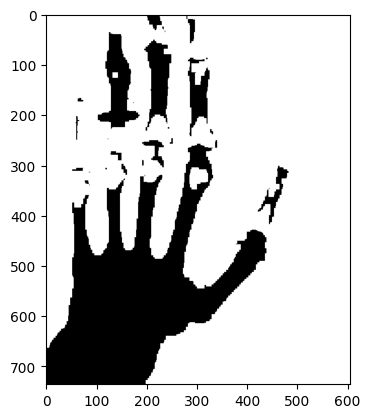

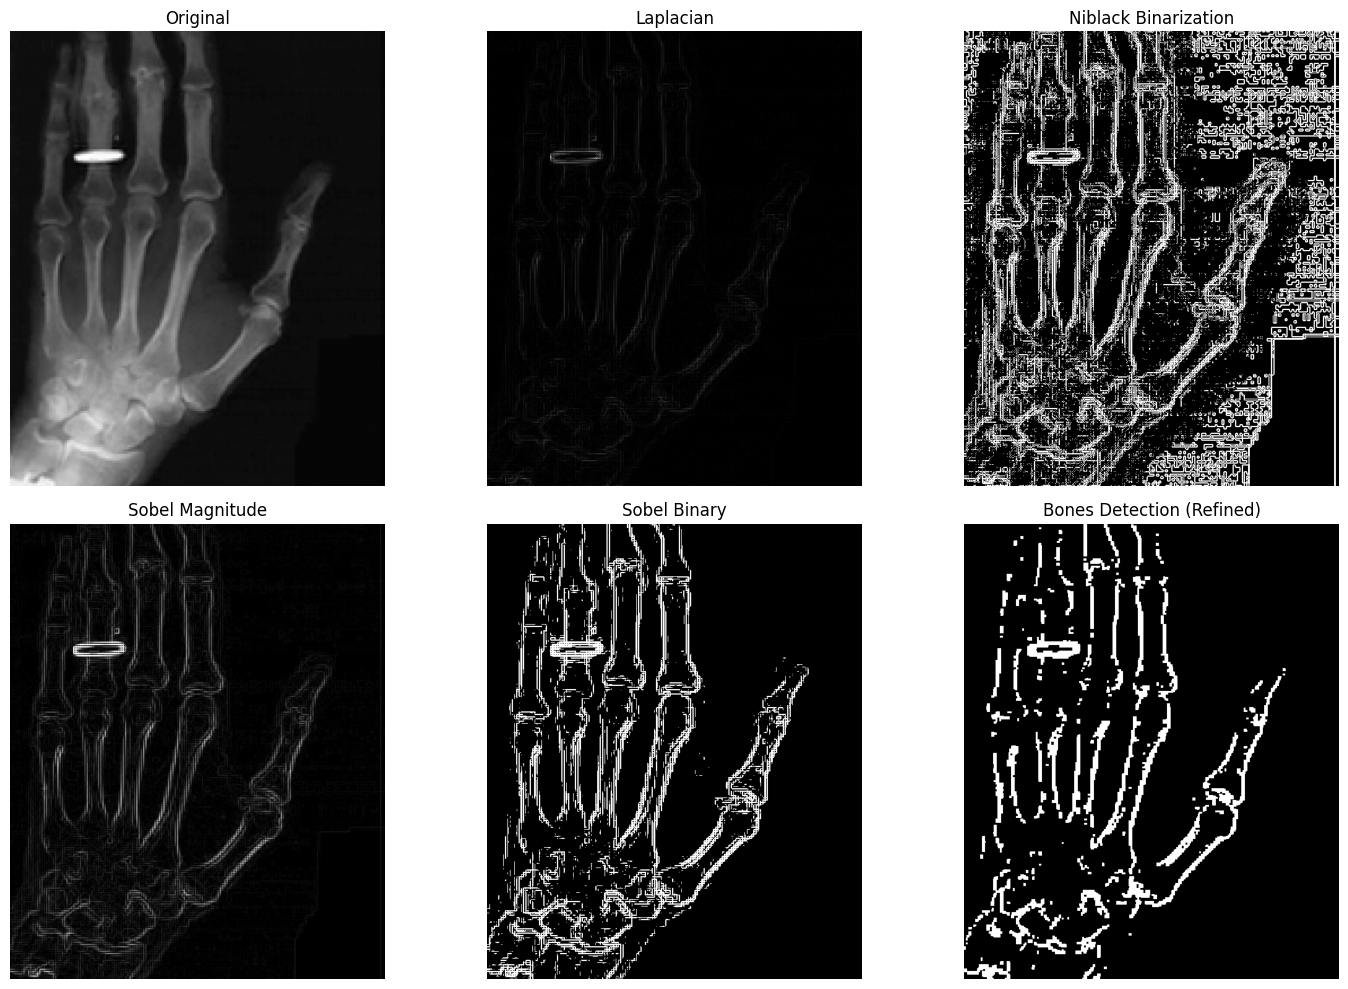

In [205]:
import cv2
import numpy as np
from skimage.filters import threshold_niblack

def detect_bones(img):

    # 2. Filtro Passa-Alta (Laplacian)
    # realce de bordas e detalhes
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    laplacian_8bit = cv2.convertScaleAbs(laplacian)

    # 3. Niblack Binarization
    # Adaptativo, bom para variações de iluminação/contraste
    # Ajuste o tamanho da janela (e.g., 15) e o parâmetro k (e.g., -0.2) conforme necessário
    binary_niblack = threshold_niblack(laplacian_8bit, window_size=101, k=-0.2)
    niblack_mask = (laplacian_8bit > binary_niblack).astype(np.uint8) * 255

    # 4. Sobel Magnitude
    # Detecta bordas fortes
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_magnitude = cv2.magnitude(sobelx, sobely)
    sobel_magnitude_8bit = cv2.convertScaleAbs(sobel_magnitude)

    # Opcional: Binarizar a magnitude Sobel para uma máscara de bordas
    _, sobel_binary = cv2.threshold(sobel_magnitude_8bit, 30, 255, cv2.THRESH_BINARY) # Ajuste o limiar

    # 5. Combinação e Refinamento (Exemplo simples: AND lógico e operações morfológicas)
    # A combinação pode variar. Aqui, usamos Niblack como base e refinamos com Sobel
    # e algumas operações morfológicas para preencher/suavizar
    combined_mask = cv2.bitwise_and(niblack_mask, niblack_mask, mask=sobel_binary) # Usando Sobel como máscara
    
    # Preenchimento de furos e remoção de pequenos ruídos
    kernel = np.ones((3,3), np.uint8) # Ajuste o tamanho do kernel
    closing = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)
    opening = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel)
    
    img_test = cv2.Canny(sobel_binary, 30, 130)
    img_test = img_test - img
    img_test = cv2.morphologyEx(img_test, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=5)
    img_test = cv2.threshold(img_test, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    plt.imshow(img_test, cmap='gray')

    # Detecção final dos ossos (apenas a área preenchida)
    # Você pode querer encontrar contornos e preencher as áreas internas dos ossos
    # Para simplicidade, vamos usar o resultado do opening como a detecção dos ossos
    bones_detection = opening
# Exibição das imagens usando matplotlib.pyplot
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    ax = axes.ravel()

    ax[0].imshow(img, cmap='gray')
    ax[0].set_title('Original')
    ax[0].axis('off')

    ax[1].imshow(laplacian_8bit, cmap='gray')
    ax[1].set_title('Laplacian')
    ax[1].axis('off')

    ax[2].imshow(niblack_mask, cmap='gray')
    ax[2].set_title('Niblack Binarization')
    ax[2].axis('off')

    ax[3].imshow(sobel_magnitude_8bit, cmap='gray')
    ax[3].set_title('Sobel Magnitude')
    ax[3].axis('off')

    ax[4].imshow(sobel_binary, cmap='gray')
    ax[4].set_title('Sobel Binary')
    ax[4].axis('off')

    ax[5].imshow(bones_detection, cmap='gray')
    ax[5].set_title('Bones Detection (Refined)')
    ax[5].axis('off')

    plt.tight_layout()
    plt.show()

# Uso
detect_bones(img) # Certifique-se de que XRay.png está no mesmo diretório

In [ ]:
blurred = cv2.GaussianBlur(
    img,
    (0, 0),
    sigmaX=3,
    sigmaY=3
)
fft_magnitude, fft_shift = apply_fourier_transform(blurred)
plt.imshow(fft_magnitude, cmap='gray')

In [ ]:
img_processed = img.copy()
for row in range(img_processed.shape[0]):
    k = True
    for col in range(img_processed.shape[1]):
        if img_processed[row, col] < np.quantile(img_processed[row, :], 0.5):
            img_processed[row, col] = 0
        else:
            img_processed[row, col] = 255

plt.imshow(img_processed, cmap='gray')

In [ ]:
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
kernel_small
cv2.

array([[0, 1, 0],
       [1, 1, 1],
       [0, 1, 0]], dtype=uint8)

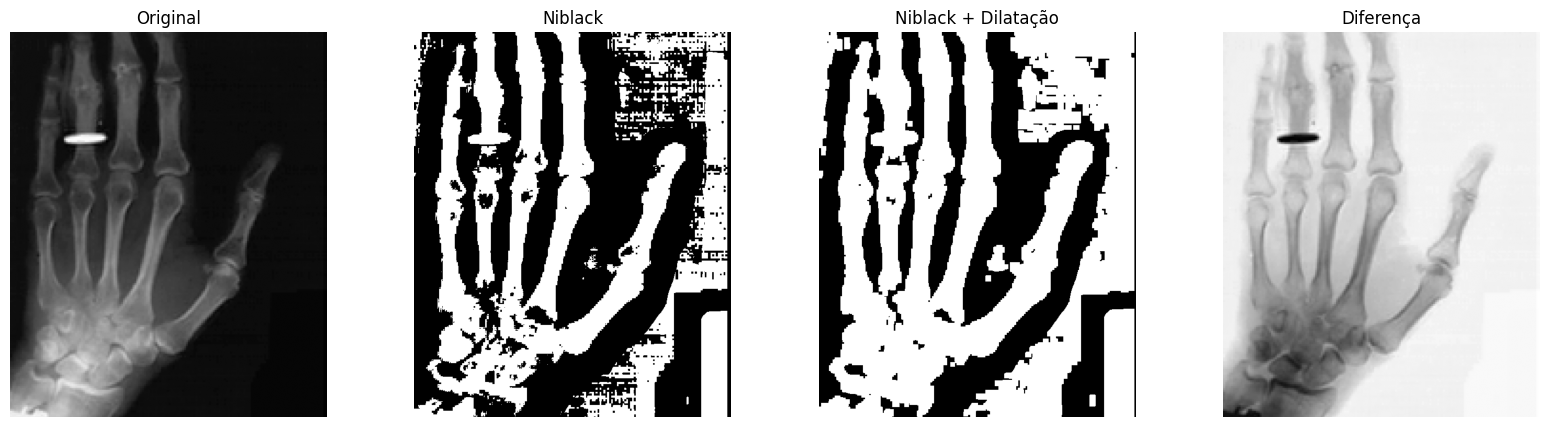

In [212]:
from skimage.filters import threshold_niblack
import matplotlib.pyplot as plt
import cv2
import numpy as np

block_size = 101  # tamanho da janela
k = -0.01         # parâmetro típico do Niblack

thresh_niblack = threshold_niblack(img, window_size=block_size, k=k)
img_niblack = (img > thresh_niblack).astype('uint8') * 255

# Expanda o branco usando dilatação morfológica
kernel = np.ones((5, 5), np.uint8)  # ajuste o tamanho do kernel conforme necessário
img_niblack_dilated = cv2.dilate(img_niblack, kernel, iterations=2)

plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(img_niblack, cmap='gray')
plt.title('Niblack')
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(img_niblack_dilated, cmap='gray')
plt.title('Niblack + Dilatação')
plt.axis('off')
plt.subplot(1, 4, 4)
plt.imshow(img_niblack_dilated - img, cmap='gray')
plt.title('Diferença')
plt.axis('off')
plt.show()

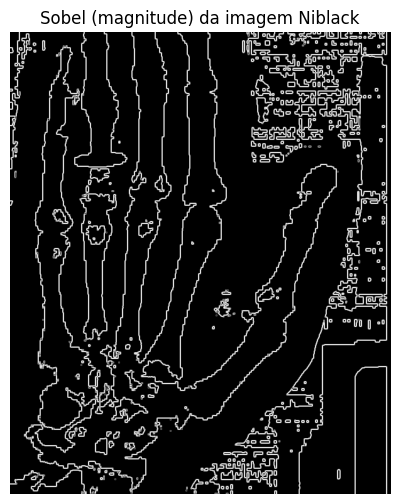

In [208]:
# Aplica o filtro de Sobel na imagem binarizada pelo Niblack
sobelx = cv2.Sobel(img_niblack, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_niblack, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobelx, sobely)
#sobel_mag = cv2.convertScaleAbs(sobel_mag)

plt.figure(figsize=(8, 6))
plt.imshow(sobel_mag, cmap='gray')
plt.title('Sobel (magnitude) da imagem Niblack')
plt.axis('off')
plt.show()

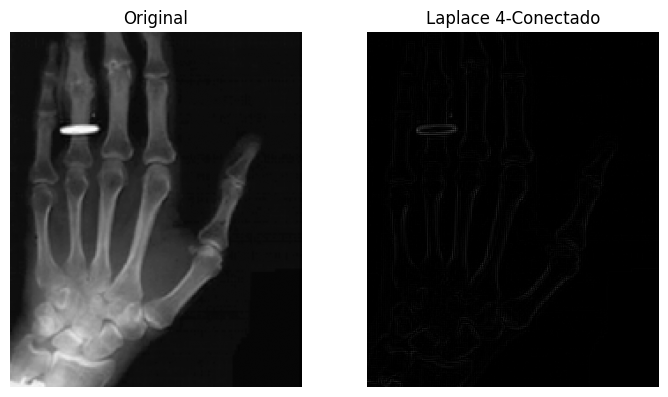

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Filtro Laplaciano 4-conectado
laplace4 = cv2.filter2D(img, -1, np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]]))

# Filtro Laplaciano 8-conectado
laplace8 = cv2.filter2D(img, -1, np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]))

# Filtro High-Boost com α = 1.5
blurred = cv2.GaussianBlur(img, (5, 5), 0)
mask = img - blurred
high_boost = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)

# Passa-alta por subtração da média (Gaussian)
highpass_sub = cv2.subtract(img, blurred)

# Mostrar todas as imagens
titles = ['Original', 'Laplace 4-Conectado', 'Laplace 8-Conectado', 'High-Boost (1.5)', 'Subtração da Média']
images = [img, laplace4]

plt.figure(figsize=(18, 4))
for i in range(len(images)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


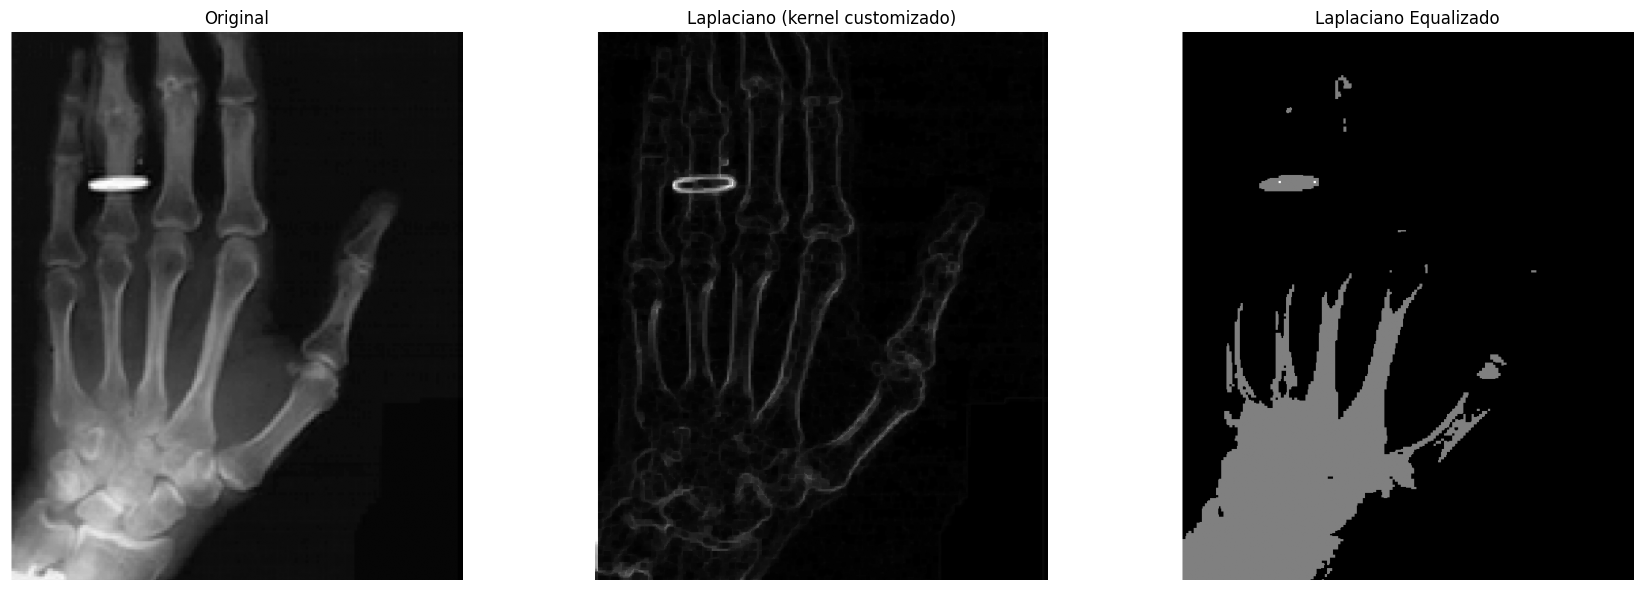

In [23]:
image = cv2.imread(path_imgs_atv / "Q2" / "XRay.png", cv2.IMREAD_GRAYSCALE)

# Definir kernel Laplaciano manualmente
kernel = np.array(
    [
        [0, 1, 1, 0],
        [1, -2, -2, 1],
        [1, -2, -2, 1],
        [0, 1, 1, 0]
    ]
)

# Aplicar o filtro Laplaciano com o kernel definido
laplacian_custom = cv2.filter2D(image, cv2.CV_64F, kernel)
laplacian_abs = cv2.convertScaleAbs(laplacian_custom)

kernel = np.ones((5,5),np.uint8)


######
# Aplique um fechamento (dilatação seguida de erosão) para fechar pequenas lacunas
laplacian_abs = cv2.morphologyEx(laplacian_abs, cv2.MORPH_CLOSE, kernel)
#################

# Equalização de histograma sobre o resultado do Laplaciano
laplacian_eq = cv2.equalizeHist(laplacian_abs)


range_values = [i for i in range(0, 256, 127)]

# Criar uma cópia da imagem para modificar
image_quant = np.zeros_like(laplacian_eq)

# Para cada faixa, atribuir o valor mínimo do intervalo
for i in range(len(range_values) - 1):
    mask = (image >= range_values[i]) & (image < range_values[i + 1])
    image_quant[mask] = range_values[i]
# Para o último intervalo (inclui o valor máximo 255)
image_quant[image >= range_values[-1]] = range_values[-1]

laplacian_eq = image_quant
# kernel = np.ones((12, 12), np.uint8)
# laplacian_eq = cv2.erode(laplacian_eq, kernel, iterations=5)

# Use a proper uint8 kernel for morphology

# Binarizar para preencher ossos
_, mask = cv2.threshold(laplacian_abs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Exibir resultados
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
# fig, ax = plt.subplots(1, 4, figsize=(18, 6))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(laplacian_abs, cmap='gray')
ax[1].set_title("Laplaciano (kernel customizado)")
ax[1].axis("off")
ax[2].imshow(laplacian_eq, cmap='gray')
ax[2].set_title("Laplaciano Equalizado")
ax[2].axis("off")
# ax[3].imshow(mask, cmap='gray')
# ax[3].set_title("Laplaciano Equalizado")
# ax[3].axis("off")
plt.tight_layout()
plt.show()

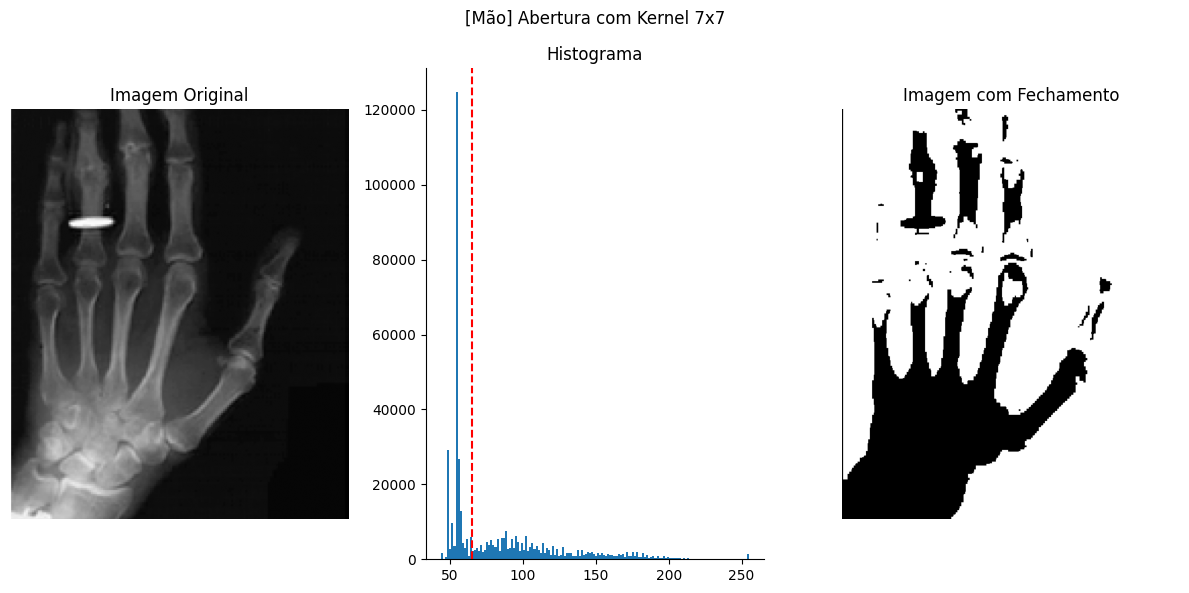

In [24]:
image = cv2.imread(path_imgs_atv / "Q2" / "XRay.png", cv2.IMREAD_GRAYSCALE)
_, image_bin = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Criar o kernel para o fechamento
kernel = np.ones((7, 7), np.uint8)

# Aplicar o Abertura
image_processed = cv2.morphologyEx(image_bin, cv2.MORPH_OPEN, kernel)

# Exibir a imagem original, o histograma e a imagem após o fechamento
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Imagem Original")
ax[0].axis('off')

ax[1].hist(image.flatten(), bins=150)
ax[1].set_title("Histograma")
ax[1].spines[["top", "right"]].set_visible(False)
ax[1].axvline(x=65, color='r', linestyle='--', label='Limiar')

ax[2].imshow(image_processed, cmap='gray')
ax[2].set_title("Imagem com Fechamento")
ax[2].axis('off')

fig.suptitle("[Mão] Abertura com Kernel 7x7")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q02-01.png", dpi=400)
plt.show()

# Questão 03

## [Logica] Agrupando tons semelhante


Como mencionado na questão, uma solução para a redução da quantidade de cores das imagens pode ser pelo meio de agrupamento de tons semelhantes para cada canal. A logica para o algoritmo esta abaixo:


* **1)**

In [ ]:
# Caminho para a imagem
images_path = {
    "araras": path_imgs_atv / "Q3" / "araras.png",
    "F1": path_imgs_atv / "Q3" / "F1.png",
    "green-water": path_imgs_atv / "Q3" / "green-water.png",
    "surf": path_imgs_atv / "Q3" / "surf.png",
}

imgs = {}
for key, path in images_path.items():
    img = cv2.imread(path)
    imgs[key] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
def count_colores(
        image: np.ndarray
    ) -> int:
    """
    Conta o número de cores únicas em uma imagem RGB.

    Args:
        image (np.ndarray): Imagem RGB.

    Returns:
        int: Número de cores únicas.
    """
    # Converte a imagem para um array 2D
    pixels = image.reshape(-1, 3)
    # Conta as cores únicas
    unique_colors = np.unique(pixels, axis=0)
    return unique_colors.shape[0]

def reduce_colors(
        image: np.ndarray,
        bins: int = 4
    ) -> np.ndarray:
    """
    Reduz a quantidade de cores de uma imagem RGB, agrupando tons semelhantes.

    Args:
        image (np.ndarray): Imagem RGB.
        bins (int): Número de intervalos para quantização em cada canal (R, G, B).

    Returns:
        np.ndarray: Imagem com cores reduzidas.
    """
    # Calcula os limites dos intervalos
    bin_edges = np.linspace(
        0,
        256,
        bins + 1,
        dtype=np.int32
    )
    bin_centers = (
        (bin_edges[:(-1)] + bin_edges[(1):]) / 2
    ).astype(int)
    
    # Mapeia cada pixel para o centro do intervalo correspondente
    quantized_image = np.zeros_like(image)
    for i in range(3):  # Para cada canal (R, G, B)
        channel = image[:, :, i]
        indices = np.digitize(channel, bin_edges) - 1
        quantized_image[:, :, i] = bin_centers[indices]

    return quantized_image, bin_centers, bin_edges

def adjust_bins(
        image: np.ndarray,
        list_range: list=[50, 150],
        target_range: tuple = (1/3, 0.5)
    ) -> int:
    """
    Ajusta o número de bins para garantir que a quantidade de cores reduzidas
    esteja dentro do intervalo desejado.

    Args:
        image (np.ndarray): Imagem RGB.
        list_range (list): Intervalo de bins a serem testados (mínimo, máximo).
        target_range (tuple):
            Intervalo desejado (mínimo, máximo) como fração da quantidade de cores originais.

    Returns:
        int: Número de bins ajustado.
    """
    original_colors = count_colores(image)
    min_colors = int(original_colors * target_range[0])  # min % do numero de cores
    max_colors = int(original_colors * target_range[1])  # max % do numero de cores

    # Testar diferentes números de bins até atingir o intervalo desejado
    for bins in range(*list_range):
        reduced_image, _, _ = reduce_colors(image, bins)
        reduced_colors = count_colores(reduced_image)
        if min_colors <= reduced_colors <= max_colors:
            return bins

    # Caso não encontre, retorna o máximo de bins permitido
    return np.min(list_range)

In [ ]:
# Aplicar a redução de cores nas imagens
reduced_imgs = {}
bins_per_image = {}
for key, img in imgs.items():
    # Ajustar dinamicamente os bins para cada imagem
    bin = adjust_bins(
        img,
        list_range=[50, 150, 10],  # parametro de procura de bins
        target_range=(1 / 3, 0.5)  # parametro de stop
    )#(1/3, 0.5))
    bins_per_image[key] = bin
    reduced_imgs[key] = reduce_colors(img, bins=bin)

In [ ]:
for key, img in reduced_imgs.items():
    img = img[0]
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path_assets / f"atv03_q03-reduced-{key}.png"), img_bgr)

In [ ]:
# Exibir as imagens originais e reduzidas
fig, ax = plt.subplots(len(reduced_imgs), 2, figsize=(16, 10))

for idx, (key, img) in enumerate(reduced_imgs.items()):
    count_original = count_colores(imgs[key])
    count_reduced = count_colores(img[0])
    count_perc = 100 * (count_reduced / count_original)

    # Imagem original
    ax[idx, 0].imshow(imgs[key])
    ax[idx, 0].set_title(f"{key} - Original ({count_original} cores)")
    ax[idx, 0].axis("off")

    # Imagem reduzida
    ax[idx, 1].imshow(img[0])
    ax[idx, 1].set_title(f"{key} - Reduzida ({count_reduced} cores | {count_perc:.2f}%)")
    ax[idx, 1].axis("off")

fig.tight_layout()
fig.savefig(path_assets / "atv03_q03_reduced_colors.png", dpi=400)
plt.show()

# Questão 04

In [ ]:
imgs = {
    "Textura1": {
        "img": read_img(path_imgs_atv / "Q4" / 'Textura1.png'),
        "img_fft": None
    },
    "Textura2": {
        "img": read_img(path_imgs_atv / "Q4" / 'Textura2.png'),
        "img_fft": None
    },
    "Textura3": {
        "img": read_img(path_imgs_atv / "Q4" / 'Textura3.png'),
        "img_fft": None
    },
}
for key, value in imgs.items():
    imgs[key]["img_fft"] = apply_fourier_transform(value["img"])[0]

In [ ]:
fig = plt.figure(figsize=(16, 12))
axes = []
for i in range(3):
    axes.append(fig.add_subplot(3, 3, i + 1))
    axes.append(fig.add_subplot(3, 3, i + 4))
    axes.append(fig.add_subplot(3, 3, i + 7, projection="3d"))

for i, (key, img) in enumerate(imgs.items()):
    # Imagem original
    axes[i * 3].imshow(img["img"], cmap="gray")
    axes[i * 3].set_title(key)
    axes[i * 3].axis("off")

    # FFT 2D
    axes[i * 3 + 1].imshow(img["img_fft"], cmap="gray")
    axes[i * 3 + 1].set_title(key + " - FFT")
    axes[i * 3 + 1].axis("off")

    # FFT 3D
    fft_magnitude = img["img_fft"]
    x = np.arange(fft_magnitude.shape[1])
    y = np.arange(fft_magnitude.shape[0])
    X, Y = np.meshgrid(x, y)
    axes[i * 3 + 2].plot_surface(X, Y, fft_magnitude, cmap="jet")
    axes[i * 3 + 2].set_title(key + " - FFT 3D")

# Ajustar layout
fig.tight_layout()
fig.savefig(path_assets / "atv03_q04-01.png", dpi=400)
plt.show()

## Solução 01) Coeficiente de varição


Vamos analisar, em conjunto, a variabilidade em torno da média da transformada de fourier, utilizando do **Coeficiente de Variação**, cuja formula pode ser expressa abaixo


$$
CV_{\%} = \frac{\sigma}{\mu} \cdot 100
$$

aonde 

$$
\begin{cases}
\sigma: \text{ Desvio padrão da magnitude da transformada de fourier} \\
\mu: \text{ Média da magnitude da transformada de fourier}
\end{cases}
$$

Para tanto, considerando que o problema é binário, vamos fixar a imagem 1 (*Textura1*) como sendo uma referencia para a classe 1, e um threshold de permissão de 5% de variabilidade sobre essa imagem de referência, para que aquela textura pertença a classe 1. Vamos por partes, abaixo calculamos o desvio padrão para cada Textura.

In [ ]:
stats_values = {}
for key, value in imgs.items():
    stats_values[key] = {
        "media": float(value["img_fft"].mean()),
        "desvio": float(value["img_fft"].std())
    }
    stats_values[key]["cv"] = 100 * (stats_values[key]["desvio"] / stats_values[key]["media"])

data_stats = pd.DataFrame(stats_values).round(2)
data_stats

Dado os coeficientes de variação acima, como definido antes, vamos utilizar o coeficiente de variação da imagem *Textura1* como referência, ou seja, 19.43%. Dessa forma, com 5% de permissão de variabilidade sobre o coeficiente de variação, temos o limite superior de 19.43% + 5% = 24.43% e limite inferior de 19.43% - 5% = 14.43%, ou seja, para que a textura seja da classe 1, então o coeficiente de variação da imagem deve estar entre  temos definido a regra abaixo:

$$
\begin{cases}
i\in \text{Classe 1}: \text{ se } 14.43 \leq cv_{i} \leq 24.43 \\
i\in \text{Classe 2}: \text{ se } cv_{i} \leq 14.43 \text{ ou } cv_{i} \geq 24.43
\end{cases}
$$

Por fim, temos um método automático para decisão se a textura exibida pertence ao mesmo padrão da 1 e da 2, ou seja, a classe 1.

Este método considera a variabilidade entre os valores de frequências na matriz de magnitudes de fourier, considerando o percentual de variabilidade em torno da média. Dessa forma, o algoritmo leva em consideração a média dos pixels e o desvio padrão da imagem.

## Solução 02) Mean Absolute Percentage Error

É possivel também, utilizando a *Textura1* como  padrão para comparação sobre a classe 1, também podemos aplicar calculos matemáticos para comparar uma nova textura com a imagem utilizada. Dessa forma, vamos utilizar a métrica conhecida como *Mean Absolute Percentage Error* (MAPE), para compararmos novas texturas com a escolhida para representar a classe 1.


A formula para o MAPE, adaptada para a situação matricial, pode ser expressa abaixo:

$$
MAPE_{\%} = 100 \cdot \sum_{j = 1}^{m}\sum_{i = 1}^{n}  \frac{|y_{ij} - \hat{y}_{ij}|}{|y_{ij}|}
$$

sendo:

$$
\begin{cases}
y_{ij}: \text{ i-ésima linha e j-ésima coluna da matriz de transformada de fourier para a matriz de referência} \\
\hat{y}_{ij}: \text{ i-ésima linha e j-ésima coluna da matriz de transformada de fourier para a matriz de comparação}
\end{cases}
$$

Será necessário considerar também um threshold para garantir um comportamento parecido entre ambas frequências na matriz de magnitude de fourier. Vamos considerar um threshold de 25% para que seja considerado uma imagem similar a de comparação, ou seja, se MAPE<sub>%</sub> < 25%, então a imagem pertence a classe 1; caso contrário, pertence a classe 2.

$$
\begin{cases}
i \in \text{Classe 1}: \text{ se } MAPE_{\%} \leq 25\% \\
i \in \text{Classe 2}: \text{ se } MAPE_{\%} > 25\%
\end{cases}
$$

Abaixo, vamos calcular esses valores:

In [ ]:
def mape(y_true, y_pred):
    """Calcula o erro percentual médio absoluto (MAPE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

img_refer = "Textura1"
data_mapes = {}
for key in ["Textura2", "Textura3"]:
    data_mapes[key] = {
        "mape": mape(
            imgs[img_refer]["img_fft"].flatten(),
            imgs[key]["img_fft"].flatten()
        )
    }
data_mapes = pd.DataFrame(data_mapes).round(2)
data_mapes

Acima, podemos ver que para a *Textura2* o valor de MAPE foi inferior ao threshold escolhido, então podemos afirmar que essa textura pertence a classe 1 também, já a *Textura3*, o valor é superior, logo pela regra sera considerado da classe 2.

Com todas as regras definidas, temos bem claro um algoritmo automático para decisão a qual classe a textura pertence.

## Solução 03) Estatística de Komolgorov-Smirnov 

In [ ]:
def ecdf(data):
    """Calcula a distribuição acumulada empírica (ECDF)."""
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cumulative

img_refer = "Textura1"
ecdfs = {}
distances = {}
# Plots
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
for key, img in imgs.items():
    dist = img["img_fft"].flatten()
    x, y = ecdf(dist)
    ecdfs[key] = {"x": x, "y": y}
    # Plotar a Distribuição de Densidade de Kernel (KDE)
    sns.kdeplot(dist, label=f"{key} - KDE", fill=True, alpha=0.3, ax=ax[0])
    
    # Calculo da estatística KS
    if key != img_refer:
        distances[key] = {
            "ks": float(ks_2samp(imgs[img_refer]["img_fft"].flatten(), dist).statistic)
        }

    # Plotar a Função de Densidade Acumulada (CDF)
    if key != img_refer:
        ax[1].plot(
            x,
            y,
            label="{} - ECDF - Distance: {:.2f}".format(key, distances[key]['ks']),
            linestyle="--"
        )
    else:
        ax[1].plot(
            x,
            y,
            label=f"{key} - ECDF",
            linestyle="--"
        )


# Configurar o gráfico
ax[0].set_title("Distribuição e Densidade Acumulada das Magnitudes da FFT")
ax[0].set_xlabel("Valores de Magnitude")
ax[0].set_ylabel("Densidade / Probabilidade Acumulada")
ax[1].set_title("Função de Densidade Acumulada (CDF)")
ax[1].set_xlabel("Valores de Magnitude")
ax[1].set_ylabel("Probabilidade Acumulada")
ax[1].set_ylim(0, 1)
for _ax in ax.flatten():
    _ax.spines[["top", "right"]].set_visible(False)
    _ax.legend()

fig.tight_layout()
fig.savefig(path_assets / "atv03_q04-02.png", dpi=400)
plt.show()

# Questão 05

In [ ]:
imgs = {
    "Merge_Timex_BoaViagem": cv2.imread(str(path_imgs_atv / "Q5" / "Merge_Timex_BoaViagem.png"))
}
img = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2HSV)

In [ ]:
# parametros
kernel_morph = np.ones((7, 7), np.uint8)  # kernel utilizado para operações morfologicas
kernel_dilate = np.ones((3, 3), np.uint8)  # kernel utilizado para dilatação 
kernel_gaussian = (3, 3)  # kernel utilizado para passa baixa gaussiana
sigma = 1  # sigma utilizado para operações morfologicas
iter_dilate = 1  # iterações de dilatação
iterations = 5  # iterações de operações morfologicas
lim_inf = 50  # corte inicial em x
lim_sup = 210  # corte final em x
c_selected = "S"  # canal a ser utilizado do HSV - Saturação (S)
threshold1 = 100  # valor minimo para o canny
threshold2 = 200  # valor maximo para o canny

In [ ]:
# Conversão para hsv
fig, ax = plt.subplots(2, 1, figsize=(16, 8))
ax[0].imshow(img)
ax[0].set_title("Imagem Original")
# ax[0].axis("off")
ax[1].imshow(img_hsv, cmap="gray")
ax[1].set_title("Imagem HSV")
# ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-01.png", dpi=400)

In [ ]:
# Recorte da imagem parte 1: 
img_cut_org = img[lim_inf:lim_sup, :]
img_cut_hsv = img_hsv[lim_inf:lim_sup, :]
fig, ax = plt.subplots(2, 1, figsize=(16, 4))
ax[0].imshow(img_cut_org)
ax[0].set_title("Imagem Original")
# ax[0].axis("off")
ax[1].imshow(img_cut_hsv, cmap="hsv")   
ax[1].set_title("Imagem HSV")
# ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-02.png", dpi=400)

In [ ]:
# Recorte da imagem parte2:
img_cut_hsv = {
    c: {
        "org": img[:, :, :],
        "hsv_cut": img_hsv[:, :, idx],
        "cut": img_hsv[lim_inf:lim_sup, :, idx]
    } for idx, c in  enumerate(["H", "S", "V"])
}

# Plotar resultado
fig, ax = plt.subplots(2, 1, figsize=(16, 8))
ax[0].imshow(img_cut_hsv[c_selected]["hsv_cut"], cmap="gray")
ax[0].set_title(f"Imagem HSV - Canal {c_selected}")
ax[0].axis("off")
ax[1].imshow(img_cut_hsv[c_selected]["cut"], cmap="gray")
ax[1].set_title(f"Recorte")
ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-03.png", dpi=400)

In [ ]:
# Aplicando o filtro passa-baixa gaussiano
img_cut_hsv[c_selected]["processed"] = cv2.GaussianBlur(
    img_cut_hsv[c_selected]["cut"],
    kernel_gaussian,
    sigmaX=sigma
)


# Plotando o resultado
fig, ax = plt.subplots(2, 1, figsize=(16, 4))
ax[0].imshow(img_cut_hsv[c_selected]["cut"], cmap="gray")
ax[0].set_title(f"Recorte")
ax[0].axis("off")
ax[1].imshow(img_cut_hsv[c_selected]["processed"], cmap="gray")
ax[1].set_title(f"... + Passa-Baixa Gaussiano")
ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-04.png", dpi=400)


In [ ]:
# Dilatação 
img_cut_hsv[c_selected]["processed_dilate"] = cv2.dilate(
    img_cut_hsv[c_selected]["processed"],
    kernel_dilate,
    iterations=iter_dilate
)

# Plotando o resultado
fig, ax = plt.subplots(2, 1, figsize=(16, 4))
ax[0].imshow(img_cut_hsv[c_selected]["processed"], cmap="gray")
ax[0].set_title(f"... + Passa-Baixa Gaussiano")
ax[0].axis("off")
ax[1].imshow(img_cut_hsv[c_selected]["processed_dilate"], cmap="gray")
ax[1].set_title(f"... + Dilatação")
ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-05.png", dpi=400)

In [ ]:
# Binarização (OTSU)
_, img_cut_hsv[c_selected]["processed_dilate_bin"] = cv2.threshold(
    img_cut_hsv[c_selected]["processed_dilate"],
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Plotando o resultado
fig, ax = plt.subplots(2, 1, figsize=(16, 4))
ax[0].imshow(img_cut_hsv[c_selected]["processed_dilate"], cmap="gray")
ax[0].set_title(f"... + Dilatação")
ax[0].axis("off")
ax[1].imshow(img_cut_hsv[c_selected]["processed_dilate_bin"], cmap="gray")
ax[1].set_title(f"... + Binarização")
ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-06.png", dpi=400)

In [ ]:
# Operação morfologica (Fechamento)
img_cut_hsv[c_selected]["processed_dilate_bin_close"] = cv2.morphologyEx(
    img_cut_hsv[c_selected]["processed_dilate_bin"],
    cv2.MORPH_CLOSE,
    kernel_morph,
    iterations=iterations
)

# Plotando o resultado
fig, ax = plt.subplots(2, 1, figsize=(16, 4))
ax[0].imshow(img_cut_hsv[c_selected]["processed_dilate_bin"], cmap="gray")
ax[0].set_title(f"... + Binarização")
ax[0].axis("off")
ax[1].imshow(img_cut_hsv[c_selected]["processed_dilate_bin_close"], cmap="gray")
ax[1].set_title(f"... + Fechamento")
ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-07.png", dpi=400)

In [ ]:
# Operação morfologica (Abertura)
img_cut_hsv[c_selected]["processed_dilate_bin_close_open"] = cv2.morphologyEx(
    img_cut_hsv[c_selected]["processed_dilate_bin_close"],
    cv2.MORPH_OPEN,
    kernel_morph,
    iterations=iterations
)

# Plotando o resultado
fig, ax = plt.subplots(2, 1, figsize=(16, 4))
ax[0].imshow(img_cut_hsv[c_selected]["processed_dilate_bin_close"], cmap="gray")
ax[0].set_title(f"... + Fechamento")
ax[0].axis("off")
ax[1].imshow(img_cut_hsv[c_selected]["processed_dilate_bin_close_open"], cmap="gray")
ax[1].set_title(f"... + Abertura")
ax[1].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-08.png", dpi=400)

In [ ]:
# Canny
img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny"] = cv2.Canny(
    img_cut_hsv[c_selected]["processed_dilate_bin_close_open"],
    threshold1=threshold1,
    threshold2=threshold2
)

# Canny dilated
img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny_dilated"] = cv2.dilate(
    img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny"],
    kernel_dilate,
    iterations=1
)


# Plotando o resultado
fig, ax = plt.subplots(3, 1, figsize=(16, 4))
ax[0].imshow(img_cut_hsv[c_selected]["processed_dilate_bin_close_open"], cmap="gray")
ax[0].set_title(f"... + Abertura")
ax[0].axis("off")
ax[1].imshow(img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny"], cmap="gray")
ax[1].set_title(f"... + Canny (Fronteira encontrada)")
ax[1].axis("off")
ax[2].imshow(img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny_dilated"], cmap="gray")
ax[2].set_title(f"Aplicando dilatação para destaque da borda")
ax[2].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-09.png", dpi=400)


In [ ]:
# Sobreposição no recorte

## Fronteira sem dilatação
img_cut_hsv[c_selected]["img_final_nodilate"] = img_cut_hsv[c_selected]["org"].copy()
img_cut_hsv[c_selected]["img_final_nodilate"][lim_inf:lim_sup, :, :][
    img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny"] > 0
] = [255] * 3
img_cut_hsv[c_selected]["cut_img_final_nodilate"] = img_cut_hsv[c_selected]["cut"].copy()
img_cut_hsv[c_selected]["cut_img_final_nodilate"][
    img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny"] > 0
] = 255


## Fronteira com dilatação
img_cut_hsv[c_selected]["img_final_dilated"] = img_cut_hsv[c_selected]["org"].copy()
img_cut_hsv[c_selected]["img_final_dilated"][lim_inf:lim_sup, :, :][
    img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny_dilated"] > 0
] = [255] * 3
img_cut_hsv[c_selected]["cut_img_final_dilated"] = img_cut_hsv[c_selected]["cut"].copy()
img_cut_hsv[c_selected]["cut_img_final_dilated"][
    img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny_dilated"] > 0
] = 255

# Plotando o resultado
fig, ax = plt.subplots(3, 1, figsize=(18, 10))
ax[0].imshow(img_cut_hsv[c_selected]["org"], cmap="gray")
ax[0].set_title("Imagem Original")
ax[0].axis("off")
ax[1].imshow(img_cut_hsv[c_selected]["img_final_nodilate"], cmap="gray")
ax[1].set_title(
    "Imagem com faixa do mar marcada"
)
ax[1].axis("off")
ax[2].imshow(img_cut_hsv[c_selected]["img_final_dilated"], cmap="gray")
ax[2].set_title(
    "Imagem com faixa do mar marcada (dilatação)"
)
ax[2].axis("off")

fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-10.png", dpi=400)

In [ ]:
imgs_dict = {
    "Filtro Passa-Baixa Gaussiano": img_cut_hsv[c_selected]["processed"],
    "... + Dilatação": img_cut_hsv[c_selected]["processed_dilate"],
    "... + Binarização (OTSU)": img_cut_hsv[c_selected]["processed_dilate_bin"],
    "... + Fechamento": img_cut_hsv[c_selected]["processed_dilate_bin_close"],
    "... + Abertura": img_cut_hsv[c_selected]["processed_dilate_bin_close_open"],
    "... + Canny": img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny"],
    "... + Dilatação (Engrossar a fronteira)": img_cut_hsv[c_selected]["processed_dilate_bin_close_open_canny_dilated"],
    "S - Recorte com fronteira": img_cut_hsv[c_selected]["cut_img_final_dilated"],
}
## Plotando todas as imagens
fig, ax = plt.subplots(len(imgs_dict), 1, figsize=(16, 20))
for i, (key, img) in enumerate(imgs_dict.items()):
    ax[i].imshow(img, cmap="gray")
    ax[i].set_title(key)
    ax[i].axis("off")
fig.tight_layout()
fig.savefig(path_assets / "atv03_q05-11.png", dpi=400)

In [ ]:
# Aumentar o desfoque (blur) para embassar mais a imagem
img_blur = cv2.GaussianBlur(img_gray, (21, 21), sigmaX=8)

# Erosão para homogeneizar a imagem antes do Otsu
kernel = np.ones((7, 7), np.uint8)
img_eroded = cv2.erode(img_blur, kernel, iterations=2)

# Aplicar Otsu na imagem erodida
thresh_otsu, img_otsu = cv2.threshold(img_eroded, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Limiar Otsu encontrado: {thresh_otsu}")

# Exibir resultado: original, blur, erodida e binarizada
fig, ax = plt.subplots(1, 4, figsize=(20, 6))
ax[0].imshow(img_gray, cmap='gray')
ax[0].set_title("Original (Gray)")
ax[0].axis('off')
ax[1].imshow(img_blur, cmap='gray')
ax[1].set_title("Após Blur Forte")
ax[1].axis('off')
ax[2].imshow(img_eroded, cmap='gray')
ax[2].set_title("Após Erosão")
ax[2].axis('off')
ax[3].imshow(img_otsu, cmap='gray')
ax[3].set_title(f"Binarização Otsu (th={thresh_otsu:.0f})")
ax[3].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
plt.hist(img_gray.flatten(), bins=150)
plt.show()

In [ ]:
imgs = {
    "Merge_Timex_BoaViagem": cv2.imread(str(path_imgs_atv / "Q5" / "Merge_Timex_BoaViagem.png"))
}
img = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(imgs["Merge_Timex_BoaViagem"], cv2.COLOR_BGR2HSV)

In [ ]:
# Se você quer converter para escala de cinza, use cv2.COLOR_BGR2GRAY
img_processed = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_processed, cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
kernel = np.ones((7, 7), np.uint8) 
kernel += kernel.sum()
img_processed = cv2.erode(img_processed, kernel, iterations=15)
plt.imshow(img_processed, cmap="gray")

In [ ]:
# Aplicar a binarização com um limiar (threshold)
_, binary_image = cv2.threshold(img_processed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Exibir a imagem original e a binarizada
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Imagem original
ax[0].imshow(img_processed, cmap="gray")
ax[0].set_title("Imagem Original")
# ax[0].axis("off")

# Imagem binarizada
ax[1].imshow(binary_image, cmap="gray")
ax[1].set_title("Imagem Binarizada")
# ax[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Aplicar o detector de bordas Canny na imagem binarizada
edges = cv2.Canny(binary_image, threshold1=100, threshold2=200)

# Exibir a imagem binarizada e as bordas detectadas
fig, ax = plt.subplots(4, 1, figsize=(16, 8))

ax[0].imshow(img, cmap="gray")

# Imagem binarizada
ax[1].imshow(binary_image, cmap="gray")
ax[1].set_title("Imagem Binarizada")
# ax[1].axis("off")

# Bordas detectadas
ax[2].imshow(edges, cmap="gray")
ax[2].set_title("Bordas Detectadas (Canny)")

edges = cv2.dilate(edges, np.ones((3, 3), np.int32), iterations=1)
img[edges > 0] = [255, 255, 255]
ax[3].imshow(img, cmap="gray")
ax[3].set_title("Bordas Detectadas (Canny)")
# ax[2].axis("off")

plt.tight_layout()
plt.show()

# Perguntas a fazer dia: 27/05/2025

## Questão 05)
1) devo escrever tambem sobre as coisas que eu testei ? ex: deixei em escala de cinza, apliquei passa baixa gaussian com 
ps: lembrar do tamanho do arquivo (~85.5mb)